# DD2 + vMIT — general first-order phase transition

A hadronic equation of state (**DD2**, a density-dependent relativistic mean field)
and a quark equation of state (**vMIT**, a vector-enhanced bag model) joined across a
first-order phase transition, with the character of that transition controlled by a
single continuous parameter **η**.

**What η means.** In a mixed phase the two phases must be electrically neutral
*somewhere*, and the question is where. η is the fraction of neutrality imposed
**locally**, inside each phase, rather than **globally**, on the volume average:

| η | construction | behaviour through the mixed window |
|---|---|---|
| 0 | **Gibbs** | only the average is neutral; the phases exchange charge freely and the pressure rises continuously |
| 1 | **Maxwell** | each phase is separately neutral; no charge is exchanged, and the window collapses to a constant-pressure plateau with a density jump |
| in between | — | stands in for the finite surface tension and Coulomb cost of the mixed-phase structures |

**How a density is classified.** The quark volume fraction χ comes out of the solve
and is *not* clamped: **χ ≤ 0 → pure hadronic, χ ≥ 1 → pure quark, 0 < χ < 1 → mixed.**
The table builder locates the two χ crossings first and then solves the expensive
mixed system only between them.

**The two sound speeds.** A first-order transition has two, and the gap between
them is the clearest single picture of what η does:

| | what is free | behaviour in the window |
|---|---|---|
| **c_eq² = dP/dε** | χ readjusts | dips at η=0, **collapses to 0** at η=1 |
| **c_ad² (frozen)** | χ held fixed | stays finite at every η |

c_eq is what enters the TOV equations; c_ad is what a fast disturbance sees.
Section III.4 plots both.

---
**Layout**
- **Part I** — imports, every knob in one cell, and a fast pre-flight check.
- **Part II** — pure phases, the mixed tables, TOV, and a parameter scan.
- **Part III** — plots, all defined here in the notebook.

**Start here if you are choosing parameters:** run Part I only. Section I.3
tells you in under a second whether your (parametrization, B4, a) has a
transition at all, before Part II spends minutes finding out the hard way.
Section II.4 then maps the region where it does.

# Part I — setup

## I.1 Imports

Imports the repository clone when the notebook sits inside one — the root is found by
walking up for `pyproject.toml` — and falls back to installing the package from GitHub
only when it does not, so a stale copy in `site-packages` can never shadow the working
tree. The line printed at the end says which copy was actually loaded.


In [1]:
import sys
import time
import subprocess
from pathlib import Path

# Import the repository clone in preference to anything pip has left behind in
# site-packages. The notebook runs from `notebooks/`, so the repository root is
# not on sys.path by default and an older installed copy of `eos` wins the
# import — one that is missing whatever subpackages have been added since it
# was installed, which is how `eos.mixed` goes absent.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "pyproject.toml").is_file() and (p / "eos").is_dir()), None)
if ROOT is not None:
    sys.path.insert(0, str(ROOT))
    # Drop anything already imported from the wrong copy, so re-running this
    # cell fixes the kernel instead of needing a restart.
    for _m in [m for m in sys.modules if m == "eos" or m.startswith("eos.")]:
        del sys.modules[_m]

try:
    import eos.mixed
except ImportError:      # not inside a clone (Colab, say) — fetch the package
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-deps",
                           "--quiet",
                           "git+https://github.com/guerrinimirco/eos.git"])
    import eos.mixed

import numpy as np
import matplotlib.pyplot as plt

from eos.dd2 import Parametrization, SpeciesFlags, hadronic_row, compute_nmp
from eos.dd2.solver import sweep_beta_eq_octet
from eos.vmit.parameters import get_vmit_default, get_vmit_custom
from eos.vmit.eos import solve_vmit_beta_eq
from eos.tov.solver import find_mmax_precise
from eos.mixed import (
    beta_eq_neutrinoless,
    MixedTableSpec, build_mixed_table, build_mixed_eos_table,
    mass_radius_mixed, save_table, load_table, export_csv,
    locate_window, sweep_mixed,
    sound_speed_eq, frozen_along,
    scan_parameters, scan_hadronic, grid_samples, DEFAULT_U_DELTA,
)
# Shared figure styling and the observational overlays, so every figure in this
# notebook reads the same way as every other figure built on `eos`. This is the
# NOTEBOOK style family (12-14 pt, gridlines, 150 dpi); `set_paper_style` /
# `paper_grid` from the same module are the manuscript counterparts, and mixing
# the two in one session means the last call wins.
from eos.general.figure_style import (
    set_global_style, setup_scientific_figure, apply_style, add_panel_labels,
    save_figure, particle_style, LABELS, STANDARD_COLORS,
)
from eos.general.observational_constraints import add_observational_constraints

set_global_style()

OUT = Path("eos_tables_DD2vMIT")
OUT.mkdir(exist_ok=True)
print("eos imported from:", Path(eos.__file__).parent)

eos imported from: /Users/mircoguerrini/Desktop/Research/Python_codes/eos/eos


## I.2 Knobs

Everything tunable lives in this cell. Edit, then run the rest.

In [ ]:
# ---- hadronic parametrization -------------------------------------------
# The default below is a *validated* nucleons + hyperons + Delta parametrization:
# it has a complete mixed phase and M_max > 2 M_sun. See the block below for what
# it is and what happens when you move off it.
#
# Other starting points:
#   from_dd2_defaults()   nucleonic DD2, no hyperon couplings
#   from_dd2y_defaults()  DD2Y (hyperons, no Delta sector) — with the vMIT
#                         defaults this has NO transition at all
#   from_nmp(NMP)         pin the nuclear-matter parameters yourself
PAR = Parametrization.from_delta_potential(
    U_Delta=-100.0, x_wD=1.2,
    base=Parametrization.from_hyperon_potentials(
        U_Lambda=-30.0, U_Sigma=30.0, U_Xi=-18.0))

# ---- which degrees of freedom exist --------------------------------------
# Every species is an explicit flag; nothing is switched on implicitly, and a
# flag that is not wired raises rather than being quietly ignored.
FLAGS = SpeciesFlags(
    hyperons=True,      # Lambda, Sigma, Xi        (needs hyperon couplings)
    deltas=True,        # Delta quartet
    muons=True,         # electrons are always present; muons optional
    phi_field=True,     # hidden-strange vector, required with hyperons
    photons=True,       # matters only at T > 0
)

# ---- quark parametrization ------------------------------------------------
# get_vmit_default() is B^1/4 = 180 MeV, a = 0.2 fm^2, m_s = 150 MeV.
# get_vmit_custom(B4=..., a=..., m_s=...) to change any of them. B4 sets how
# costly quark matter is (higher -> later transition, or none at all) and a is
# the vector coupling (higher -> stiffer quark matter -> larger M_max).
VMIT = get_vmit_custom(B4=180.0, a=0.15, m_s=150.0)

# ---- WHY THIS PARAMETRIZATION ---------------------------------------------
# It is one of 605 combinations (out of 5904 scanned with I.4's machinery) that
# satisfy BOTH requirements at once: a complete mixed phase — chi crosses 0 and
# 1, in that order — and M_max > 2 M_sun with hyperons and Deltas active.
#
#   nuclear matter   DD2's own NMP, unchanged (L_sym = 55.03 MeV). The isoscalar
#                    cross-constraint locks K_sat to ~243 anyway, so there is
#                    little to gain by moving them;
#   hyperons         the DD2Y potentials, unchanged: U_Lambda = -30,
#                    U_Sigma = +30, U_Xi = -18 MeV. The scan found these make
#                    almost no difference to whether a hybrid star exists,
#                    because the transition sits at or below the hyperon
#                    threshold — so there is no reason not to use the
#                    literature values;
#   Delta isobars    U_Delta = -100 MeV with x_omegaDelta = 1.2. This is the
#                    only setting that departs from the published tables, and it
#                    is the one that matters: x_omegaDelta = 1.0 at this U_Delta
#                    drives the effective mass to zero (scalar collapse) near
#                    0.9 fm^-3, and across the whole scan x_omegaDelta = 1.2 was
#                    about four times more likely to give a viable star;
#   quarks           B^1/4 = 180 MeV, a = 0.15 fm^2, m_s = 150 MeV.
#
# At eta = 0 it gives a complete window at 0.93-1.23 fm^-3 (6.2-8.2 n_sat),
# M_max = 2.05 M_sun, R(1.4) = 12.90 km, max c_s^2 = 0.505.
#
# It was chosen over the other viable combinations for one practical reason:
# it is one of the few that completes at EVERY eta in ETA_LIST, and the windows
# nest monotonically as eta rises — [0.93, 1.23] at eta = 0 shrinking to
# [1.00, 1.17] at eta = 1 — which is the textbook Gibbs-to-Maxwell picture and
# what every eta-family figure in Part III is drawing. Combinations that are
# heavier but drop the window at one or two intermediate eta (B^1/4 = 160,
# a = 0.20 reaches 2.07 M_sun but has no window at eta = 0.6) leave holes in
# those figures.
#
# Moving off it, in rough order of how much it costs you:
#
#   a          THE binding constraint. Only 0.05 <= a <= 0.20 fm^2 works at all:
#              a = 0 leaves the quark phase too soft to reach 2 M_sun, and from
#              a = 0.25 upward there is no ordered window for ANY B^1/4 in
#              [120, 200] MeV — chi comes back decreasing in density instead of
#              rising, which is an unexplained boundary rather than a physical
#              one, so do not read it as a bound on the vMIT vector coupling;
#   B^1/4      trades off against a: both raise the onset density, so they move
#              in OPPOSITE directions. a = 0.20 wants B^1/4 ~ 150-190;
#              a = 0.10 wants ~190-200. Raise B^1/4 alone and the transition
#              leaves the grid;
#   x_wD       1.2 works far more often than 1.0 (see above);
#   L_sym      free over 30-100 MeV, and it barely moves the result;
#   U_Y, m_s   no measurable effect on viability.

# ---- equilibrium mode -----------------------------------------------------
# 'beta_eq_neutrinoless'      independent variables (nB, T)
# 'beta_eq_neutrino_trapped'  independent variables (nB, Y_L, T)
# 'fixed_YC'                  independent variables (nB, Y_C, T)
# 'fixed_YC_YS'               independent variables (nB, Y_C, Y_S, T)
#
# Y_C is the NON-leptonic charge fraction (hadrons and quarks only); Y_S counts
# +1 per s-quark. The fixed-fraction modes sweep their fraction as an extra
# table axis, taken from the list below.
MODE = "beta_eq_neutrinoless"
FIXED = {}                      # scalar values for fractions not swept as axes
Y_C_LIST = [0.05, 0.1, 0.3]     # the Y_C axis, for the fixed-Y_C modes

# ---- grids ----------------------------------------------------------------
N_SAT = PAR.n_sat                                     # fm^-3
NB = np.linspace(0.1 * N_SAT, 12.0 * N_SAT, 300)      # baryon density [fm^-3]
# T_LIST x ETA_LIST is what Part II.2 costs: one window search plus one window
# sweep per pair. The 12 x 5 default is a full production run (minutes); for a
# first look cut T_LIST to [0.0, 10.0, 30.0] and ETA_LIST to [0.0, 1.0].
T_LIST = [0.0, 0.1, 2.5, 5.0, 7.5, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0]
ETA_LIST = [0.0, 0.1, 0.3, 0.6, 1.0]

# ---- what to run ----------------------------------------------------------
TOV_ETAS = [0.0, 0.1, 0.3, 0.6, 1.0]      # TOV is beta-equilibrium, T = 0 only

# ---- parameter scan (II.4) ------------------------------------------------
# The map of where a hybrid star exists at all. Kept coarse by default; each
# (B4, a) pair costs roughly a second with TOV on.
SCAN_B4 = [150.0, 160.0, 170.0, 180.0, 190.0]     # MeV
SCAN_A = [0.05, 0.10, 0.15, 0.20]                 # fm^2 (>= 0.25 has no window)
SCAN_GRID = np.linspace(0.05, 1.6, 120)           # coarser than NB: a probe
SCAN_TOV = True                                   # also record M_max, R_1.4

# The hyperon couplings live in DD2Y and nowhere else — DD2 has no entry for
# Lambda — so `hyperons=True` on `from_dd2_defaults()` fails deep in the
# coupling lookup with a bare KeyError. Catch the mismatch here instead.
if FLAGS.hyperons and not PAR.hyperon_coupling_map:
    raise ValueError("FLAGS.hyperons=True needs a parametrization that carries "
                     "hyperon couplings — from_dd2y_defaults() or "
                     "from_hyperon_potentials(); the DD2 defaults carry none")

print(f"n_sat = {N_SAT:.6f} fm^-3")
print(f"n_B  : {NB[0]:.4f} .. {NB[-1]:.4f} fm^-3  ({len(NB)} points, "
      f"{NB[0]/N_SAT:.1f}-{NB[-1]/N_SAT:.1f} n_sat)")
print(f"T    : {T_LIST}")
print(f"eta  : {ETA_LIST}")
print(f"mode : {MODE};  species: "
      f"{'hyperons ' if FLAGS.hyperons else ''}{'deltas ' if FLAGS.deltas else ''}"
      f"{'muons ' if FLAGS.muons else ''}nucleons+electrons")
print(f"vMIT : B^1/4={VMIT.B4} MeV, a={VMIT.a} fm^2, m_s={VMIT.m_s} MeV")
print(f"\nNote: below ~0.5 n_sat and at low T, uniform matter sits inside the")
print(f"liquid-gas spinodal and has no stable solution; those points are skipped.")

n_sat = 0.149065 fm^-3
n_B  : 0.0149 .. 1.7888 fm^-3  (300 points, 0.1-12.0 n_sat)
T    : [0.0, 0.1, 2.5, 5.0, 7.5, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0]
eta  : [0.0, 0.1, 0.3, 0.6, 1.0]
mode : beta_eq_neutrinoless;  species: nucleons+electrons
vMIT : B^1/4=180.0 MeV, a=0.2 fm^2, m_s=150.0 MeV

Note: below ~0.5 n_sat and at low T, uniform matter sits inside the
liquid-gas spinodal and has no stable solution; those points are skipped.


## I.3 Pre-flight — does this combination have a transition?

Under a second, and it answers the question Part II would otherwise take minutes
to answer. The quark volume fraction χ is not clamped, so the window locator
simply reads off where χ crosses 0 and 1:

- **a window** → the parameters give a complete transition, go on to Part II;
- **no window** → χ never reaches 1. Either the hadronic phase never becomes
  unfavourable (lower `B4`) or the transition starts and stalls. This is a
  statement about the physics of your parameters, not a solver failure.

η=1 (Maxwell) is checked alongside η=0 (Gibbs) because the window narrows with η,
and a combination that transitions under Gibbs can fail to under Maxwell.

In [3]:
print(f"pre-flight  B4={VMIT.B4:.0f} MeV  a={VMIT.a} fm^2  m_s={VMIT.m_s:.0f} MeV")
_ok = []
for _eta in (0.0, 1.0):
    _t0 = time.time()
    _w = locate_window(PAR, FLAGS, NB, _eta, beta_eq_neutrinoless(),
                       vmit_params=VMIT, T=0.0)
    _ok.append(_w.exists)
    if _w.exists:
        print(f"  eta={_eta}: window [{_w.n_onset:.4f}, {_w.n_offset:.4f}] fm^-3 "
              f"= [{_w.n_onset/N_SAT:.2f}, {_w.n_offset/N_SAT:.2f}] n_sat "
              f"({time.time()-_t0:.2f} s)")
    else:
        print(f"  eta={_eta}: NO TRANSITION on this grid ({time.time()-_t0:.2f} s)")

if not any(_ok):
    print("\n-> No transition at either eta. Part II will produce a pure hadronic")
    print("   equation of state, which is a valid answer but not a hybrid one.")
    print("   Lower B4 (try 160-165 MeV) or run II.4 to see where the window is.")
elif not all(_ok):
    print("\n-> Gibbs transitions but Maxwell does not (or vice versa). The eta")
    print("   sweep in Part II will show empty tables for the eta that fails.")
else:
    print("\n-> Complete transition at both eta. Part II is worth running.")

pre-flight  B4=180 MeV  a=0.2 fm^2  m_s=150 MeV
  eta=0.0: window [0.4319, 1.0820] fm^-3 = [2.90, 7.26] n_sat (0.27 s)
  eta=1.0: window [0.6385, 0.8779] fm^-3 = [4.28, 5.89] n_sat (0.18 s)

-> Complete transition at both eta. Part II is worth running.


## I.4 Choosing parameters — a two-stage scan

Two questions, answered in the order that fails cheapest, **with hyperons and Δ
isobars switched on** regardless of what `FLAGS` says above (this section builds its
own parametrizations from nuclear-matter parameters, so it is independent of the
`PAR` chosen in I.2).

**Stage 1 — which NMP give a working DD2 at all?** Four checks per sample:

| check | what fails it |
|---|---|
| `inversion_ok` | the NMPs have no DD-RMF realisation |
| `sectors_ok` | the hyperon / Δ scalar couplings do not invert on that base |
| `sweep_ok` | the β-eq sweep does not reach `n_sweep_min` before scalar collapse |
| `M_max_had` | the hadronic branch alone misses 2 M_sun |

**The hadronic sector potentials are scan axes too.** `U_Lambda`, `U_Sigma`, `U_Xi`,
`U_Delta` and the Δ vector ratios `x_wD` / `x_rD` may be put in the *same* sample
dicts as the nuclear-matter parameters; the scan splits them out and inverts each
sector on top of the nucleon base. They matter far more than the NMP do, because they
set how soft the hadronic branch becomes: `x_wD` alone moves the viable fraction by
a factor of ~4, while `U_Lambda` and `U_Xi` barely move it at all once the transition
sits below the hyperon threshold. `U_Delta` is restricted to the literature range
[-100, -50] MeV by `from_delta_potential`, and `U_Delta = -100` with `x_wD = 1.0` is
soft enough to hit scalar collapse near 0.9 fm⁻³ — reported as `sweep_truncated`,
which is *not* disqualifying (see the stage-1 filter note below).

**Read this before choosing NMP axes.** `L_sym` is free — the isovector inversion is
near-analytic and converges across 30–100 MeV. **`K_sat` is not**: the isoscalar
system is closed by a cross-constraint that ties `K_sat` to `Q_sat`, so moving
`K_sat` alone leaves a residual that grows away from the DD2 value (~3e-2 at 240 MeV
against a 2e-2 gate, 0.2 by 220 MeV). The `K_sat` column below is included precisely
so you can *see* that — it will report `inversion_failed` everywhere except at DD2's
own value. That is a statement about the DD2 functional form, not a solver defect.

**Stage 2 — which of those, crossed with the quark parameters (B^1/4, a, m_s), give
M_max > 2 M_sun, and which of those actually have a phase transition?** Those are
two different questions and the table reports both: a combination can be heavy
enough without transitioning (it is then just a hyperonic star), and it can
transition without being heavy enough.

**A third outcome, and with hyperons and Δ isobars on it is the most common one:
`eos_unphysical`.** The χ=0 crossing that the window locator finds can be spurious
at a low bag constant — the mixed branch it locks onto sits at a *lower* pressure
than the hadronic branch at the same density, so it is not the favoured state, and
the stitched table steps *down* by tens of MeV/fm³ at the onset. Such a table is not
an equation of state, and integrating it returns confident nonsense (maximum masses
in the hundreds of solar masses). The scan therefore checks P is non-decreasing and
0 ≤ c_s² ≤ 1 **before** integrating, and reports `eos_unphysical` instead of a
number. Expect a large fraction of the "has a transition" cells to be rejected here;
that rejection is the scan working, not failing.

In [4]:
# ---- stage-1 axes ---------------------------------------------------------
# The hadronic sector potentials go in the SAME sample dicts as the NMP: the
# scan splits them out and inverts each on top of the nucleon base, so one
# grid_samples call crosses nuclear-matter parameters with hyperon and Delta
# potentials.
SCAN_FLAGS = SpeciesFlags(hyperons=True, deltas=True, muons=True,
                          phi_field=True, photons=True)
SCAN_K_SAT = [230.0, 242.7]             # see the note above: only ~242.7 inverts
SCAN_L_SYM = [30.0, 55.0, 85.0]
SCAN_U_LAMBDA = [-30.0, -10.0]          # MeV, hyperon potentials in SNM at n_sat
SCAN_U_XI = [-18.0, 10.0]
SCAN_U_DELTA = [-50.0, -100.0]          # MeV, from_delta_potential range limit
SCAN_X_WD = [1.0, 1.2]                  # Delta vector ratio x_omegaDelta
SCAN_NMP_GRID = np.linspace(0.05, 1.6, 80)   # a probe grid, coarser than NB

# ---- stage-2 axes (crossed with whatever survives stage 1) -----------------
# a and B^1/4 both raise the onset density, so the viable combinations sit on
# an anticorrelated ridge: a = 0.20 wants B^1/4 ~ 160-180, a = 0.10 wants
# ~190-200. Outside 0.05 <= a <= 0.20 nothing survives — a = 0 leaves the quark
# phase too soft to reach 2 M_sun, and by a = 0.25 the ordered window is gone
# for every bag constant from 120 to 200 MeV.
SCAN2_B4 = [170.0, 180.0, 190.0]        # MeV
SCAN2_A = [0.10, 0.15, 0.20]            # fm^2
SCAN2_MS = [100.0, 150.0]               # MeV
SCAN_N_JOBS = -1                        # 1 to keep it serial and debuggable

BASE_NMP = compute_nmp(Parametrization.from_dd2_defaults())
_scan_axes = {k: v for k, v in BASE_NMP.items()
              if k not in ("K_sat", "L_sym")}      # these two go on axes below
nmp_samples = grid_samples(**_scan_axes, K_sat=SCAN_K_SAT, L_sym=SCAN_L_SYM,
                           U_Lambda=SCAN_U_LAMBDA, U_Xi=SCAN_U_XI,
                           U_Delta=SCAN_U_DELTA, x_wD=SCAN_X_WD)

print(f"STAGE 1 — {len(nmp_samples)} hadronic samples, hyperons+deltas")
t0 = time.time()
had_rows = scan_hadronic(nmp_samples, SCAN_FLAGS, SCAN_NMP_GRID, tov=True,
                         n_jobs=SCAN_N_JOBS)
print(f"  K_sat  L_sym    U_L   U_Xi    U_D  x_wD | inv sec swp  n_max  "
      f"M_max_had | status")
for r in had_rows:
    print(f"  {r['K_sat']:6.1f} {r['L_sym']:5.1f} {r['U_Lambda']:6.1f} "
          f"{r['U_Xi']:6.1f} {r['U_Delta']:6.1f} {r['x_wD']:5.2f} |  "
          f"{r['inversion_ok']:.0f}   {r['sectors_ok']:.0f}   "
          f"{r['sweep_ok']:.0f}  {r['n_sweep_max']:5.2f}  "
          f"{r['M_max_had']:9.3f} | {r['status']}")

# Everything whose couplings exist goes through to stage 2 — NOT only
# status == 'ok'. Both of the other outcomes are survivable:
#   'hadronic_M_max_low' — the hadronic branch alone misses 2 M_sun, which
#       quark matter can and does fix;
#   'sweep_truncated'    — the beta-eq sweep hit scalar collapse before the top
#       of the grid, but the hadronic branch only has to reach the transition
#       ONSET, not the top. Filtering these out drops real hybrid stars.
had_ok = [(s, r) for s, r in zip(nmp_samples, had_rows)
          if r["sectors_ok"] == 1.0]
print(f"\n-> {len(had_ok)}/{len(had_rows)} hadronic samples have couplings "
      f"({time.time()-t0:.1f} s); "
      f"{sum(1 for _, r in had_ok if r['status'] == 'ok')} pass every check")
if not had_ok:
    print("   None. Stage 2 has nothing to cross; widen SCAN_L_SYM or relax "
          "the M_max target.")

STAGE 1 — 15 NMP samples, hyperons+deltas, U_Delta=-50 MeV
  K_sat  L_sym | inv sec swp  n_max  M_max_had  R_1.4 | status
   230.0  30.0 |  0   0   0    nan       nan     nan | inversion_failed
   230.0  45.0 |  0   0   0    nan       nan     nan | inversion_failed
   230.0  55.0 |  0   0   0    nan       nan     nan | inversion_failed
   230.0  70.0 |  0   0   0    nan       nan     nan | inversion_failed
   230.0  85.0 |  0   0   0    nan       nan     nan | inversion_failed
   242.7  30.0 |  1   1   1   1.29     2.043   12.80 | ok
   242.7  45.0 |  1   1   1   1.29     2.036   13.01 | ok
   242.7  55.0 |  1   1   1   1.29     2.030   13.18 | ok
   242.7  70.0 |  1   1   1   1.29     2.018   13.48 | ok
   242.7  85.0 |  1   1   1   1.31     2.010   13.86 | ok
   255.0  30.0 |  0   0   0    nan       nan     nan | inversion_failed
   255.0  45.0 |  0   0   0    nan       nan     nan | inversion_failed
   255.0  55.0 |  0   0   0    nan       nan     nan | inversion_failed
   255.0  70

In [5]:
# ---- STAGE 2: the working NMP crossed with the quark parameters -----------
good_nmp = [s for s, _ in had_ok]
vmit_samples = grid_samples(B4=SCAN2_B4, a=SCAN2_A, m_s=SCAN2_MS)

print(f"STAGE 2 — {len(good_nmp)} NMP x {len(vmit_samples)} vMIT "
      f"= {len(good_nmp)*len(vmit_samples)} combinations")
t0 = time.time()
hyb_rows = scan_parameters(good_nmp, vmit_samples, SCAN_FLAGS, SCAN_NMP_GRID,
                           eta=0.0, T=0.0, tov=True, n_jobs=SCAN_N_JOBS)

from collections import Counter

_trans = [r for r in hyb_rows if r["window_exists"] == 1.0]
_bad = [r for r in hyb_rows if r["status"] == "eos_unphysical"]
_heavy = [r for r in hyb_rows
          if np.isfinite(r.get("M_max", np.nan)) and r["M_max"] > 2.0]
_both = [r for r in _heavy if r["window_exists"] == 1.0]

print(f"\n  {len(_trans):3d}/{len(hyb_rows)} have a phase transition")
print(f"  {len(_bad):3d}/{len(hyb_rows)} of those stitch to an UNPHYSICAL EoS "
      f"(rejected before TOV)")
print(f"  {len(_heavy):3d}/{len(hyb_rows)} reach M_max > 2.0 Msun")
print(f"  {len(_both):3d}/{len(hyb_rows)} do BOTH  <- the viable hybrid stars")
print(f"\n  status breakdown: {dict(Counter(r['status'] for r in hyb_rows))}")

print(f"\n  L_sym    U_L   U_Xi    U_D  x_wD |    B4     a    m_s | "
      f"transition          M_max   R_1.4  cs2max")
for r in sorted(_both, key=lambda r: -r["M_max"])[:25]:
    print(f"  {r['L_sym']:5.1f} {r['U_Lambda']:6.1f} {r['U_Xi']:6.1f} "
          f"{r['U_Delta']:6.1f} {r['x_wD']:5.2f} | {r['B4']:5.1f}  "
          f"{r['a']:.2f} {r['m_s']:5.1f} | "
          f"[{r['n_onset']:.3f},{r['n_offset']:.3f}] fm^-3  "
          f"{r['M_max']:6.3f}  {r['R_1p4']:5.2f}  {r['cs2_max']:.3f}")
if not _both:
    print("  (none in this grid — a and B^1/4 both raise the onset, so move")
    print("   them in OPPOSITE directions: lower SCAN2_B4 if a is at 0.20,")
    print("   raise it towards 200 if a is at 0.10. Going above a = 0.20 does")
    print("   not help; the ordered window is gone there for any B^1/4.)")
elif _heavy and not _both:
    print("  (none — every heavy-enough combination is a pure hyperonic star)")
print("\n  Note: an onset below ~2 n_sat is formally allowed by these checks but")
print("  physically doubtful — uniform matter is not the ground state there.")
print(f"\n({time.time()-t0:.1f} s)")

save_table(had_rows, OUT / "scan_stage1_nmp.h5", meta=dict(flags=SCAN_FLAGS))
save_table(hyb_rows, OUT / "scan_stage2_hybrid.h5", meta=dict(flags=SCAN_FLAGS))
export_csv(hyb_rows, OUT / "scan_stage2_hybrid.csv")

STAGE 2 — 5 NMP x 12 vMIT = 60 combinations

   27/60 have a phase transition
   21/60 of those stitch to an UNPHYSICAL EoS (rejected before TOV)
    4/60 reach M_max > 2.0 Msun
    4/60 do BOTH  <- the viable hybrid stars

  status breakdown: {'no_window': 33, 'ok': 6, 'eos_unphysical': 21}

  L_sym    B4     a    m_s | transition          M_max   R_1.4  cs2max
   30.0 155.0  0.20 100.0 | [0.191,0.556] fm^-3   2.090  11.92  0.513
   30.0 165.0  0.20 100.0 | [0.239,1.102] fm^-3   2.050  12.52  0.513
   70.0 165.0  0.20 100.0 | [0.204,1.036] fm^-3   2.039  12.85  0.513
   85.0 165.0  0.20 150.0 | [0.953,1.318] fm^-3   2.009  13.85  0.538

  Note: an onset below ~2 n_sat is formally allowed by these checks but
  physically doubtful — uniform matter is not the ground state there.

(27.4 s)


PosixPath('eos_tables_DD2vMIT/scan_stage2_hybrid.csv')

# Part II — tables

The build proceeds in the order the physics suggests:

1. **the two pure phases** on the whole density grid — cheap, and they are both the
   seeds for the mixed solve and the wings of the final table;
2. **the transition boundaries**, found by reading χ and bracketing its 0 and 1
   crossings;
3. **the mixed phase**, solved only between those boundaries, warm-started from one
   density to the next.

## II.1 Pure phases

Useful on their own, and a quick check that both engines cover the grid before the
expensive part starts.

In [6]:
def _columns(rows):
    """A list of flat dicts to a {name: array} table.

    String label columns (`phase`) are dropped — everything below slices and
    plots numerically, so carrying them would only force a dtype check at
    every use.
    """
    return {k: np.array([r[k] for r in rows], dtype=float) for k in rows[0]
            if not isinstance(rows[0][k], str)}


def _quark_row(q):
    """One pure-quark point, keyed like `hadronic_row` / `composition_row`, so
    the pure wings and the mixed window concatenate in Part III without
    renaming anything. chi = 1: no hadronic matter left."""
    return dict(n_B=q.n_B, T=q.T, chi=1.0, P=q.P_total, eps=q.e_total,
                s=q.s_total, S_per_B=(q.s_total / q.n_B if q.n_B else 0.0),
                mu_B=q.mu_B, Y_C=q.Y_C, Y_S=q.Y_S,
                Y_u=q.Y_u, Y_d=q.Y_d, Y_s=q.Y_s, Y_e=q.Y_e)


t0 = time.time()
pure_hadronic = {}
for T in T_LIST:
    pts = sweep_beta_eq_octet(PAR, NB, FLAGS, T=T, stop_at_boundary=True)
    if pts:
        # `hadronic_row` keys a pure-hadronic point exactly the way
        # `composition_row` keys a mixed one. It also sums Y_C and Y_S over
        # every active baryon rather than reading them off the proton, which
        # matters the moment hyperons are switched on.
        pure_hadronic[T] = _columns([hadronic_row(p, FLAGS) for p in pts])
    print(f"  hadronic T={T:5.1f} MeV : {len(pts):3d}/{len(NB)} points", flush=True)
print(f"pure hadronic: {time.time()-t0:.1f} s\n")

t0 = time.time()
pure_quark = {}
for T in T_LIST:
    rows = []
    for n in NB:
        try:
            rows.append(_quark_row(solve_vmit_beta_eq(float(n), T, params=VMIT)))
        except Exception:
            continue
    if rows:
        pure_quark[T] = _columns(rows)
    print(f"  quark    T={T:5.1f} MeV : {len(rows):3d}/{len(NB)} points", flush=True)
print(f"pure quark: {time.time()-t0:.1f} s")

  hadronic T=  0.0 MeV : 300/300 points
  hadronic T=  0.1 MeV : 300/300 points
  hadronic T=  2.5 MeV : 300/300 points
  hadronic T=  5.0 MeV : 300/300 points
  hadronic T=  7.5 MeV : 300/300 points
  hadronic T= 10.0 MeV : 300/300 points
  hadronic T= 15.0 MeV : 300/300 points
  hadronic T= 20.0 MeV : 300/300 points
  hadronic T= 25.0 MeV : 300/300 points
  hadronic T= 30.0 MeV : 300/300 points
  hadronic T= 40.0 MeV : 300/300 points
  hadronic T= 50.0 MeV : 300/300 points
pure hadronic: 0.9 s

  quark    T=  0.0 MeV : 300/300 points
  quark    T=  0.1 MeV : 300/300 points
  quark    T=  2.5 MeV : 300/300 points
  quark    T=  5.0 MeV : 300/300 points
  quark    T=  7.5 MeV : 300/300 points
  quark    T= 10.0 MeV : 300/300 points
  quark    T= 15.0 MeV : 300/300 points
  quark    T= 20.0 MeV : 300/300 points
  quark    T= 25.0 MeV : 300/300 points
  quark    T= 30.0 MeV : 300/300 points
  quark    T= 40.0 MeV : 300/300 points
  quark    T= 50.0 MeV : 300/300 points
pure quark: 0.6 s


## II.2 Mixed tables

One table per η (η changes the size of the unknown vector, so it is looped outside
rather than being an axis). Each line prints its transition window, how many points
it converged, and the cost per point.

In [7]:
def progress(info):
    """Called once per axis combination by build_mixed_table."""
    w = info["window"]
    span = (f"[{w.n_onset:.4f}, {w.n_offset:.4f}] fm^-3"
            if (w is not None and w.exists) else "no transition")
    per = 1e3 * info["seconds"] / max(info["n_points"], 1)
    extra = "".join(f" {k}={v:.3f}" for k, v in info["fractions"].items())
    print(f"    {info['temp_key']}={info['temp']:5.1f}{extra} | window {span:32s}"
          f" | {info['n_points']:3d} pts | {info['seconds']:6.1f} s"
          f" | {per:6.1f} ms/pt", flush=True)


tables, windows_by_eta = {}, {}
grand_total = time.time()
for eta in sorted(ETA_LIST):          # ascending, so each eta seeds the next
    print(f"\neta = {eta}")
    t0 = time.time()
    axes = {"nB": NB, "T": T_LIST}
    if MODE in ("fixed_YC", "fixed_YC_YS"):
        axes["Y_C"] = Y_C_LIST
    spec = MixedTableSpec(PAR, FLAGS, MODE, axes=axes, eta=eta,
                          vmit_params=VMIT, fixed=FIXED, leptons=True)
    rows, windows = build_mixed_table(spec, progress=progress)
    tables[eta], windows_by_eta[eta] = rows, windows

    meta = dict(mode=MODE, eta=eta, parametrization=PAR, flags=FLAGS, vmit=VMIT,
                nB_grid=NB, T_grid=T_LIST)
    path = OUT / f"mixed_{MODE}_eta{eta:.2f}.h5"
    save_table(rows, path, meta=meta, windows=windows)
    export_csv(rows, path.with_suffix(".csv"), meta=meta)
    print(f"  -> {len(rows)} rows in {time.time()-t0:.1f} s, saved {path.name}")

print(f"\nTOTAL: {time.time()-grand_total:.1f} s for "
      f"{sum(len(r) for r in tables.values())} mixed points")


eta = 0.0
    T=  0.0 | window [0.4319, 1.0820] fm^-3           | 109 pts |    0.5 s |    5.0 ms/pt
    T=  0.1 | window [0.4319, 1.0820] fm^-3           | 109 pts |    0.9 s |    8.1 ms/pt
    T=  2.5 | window [0.4319, 1.0820] fm^-3           | 109 pts |    0.9 s |    8.4 ms/pt
    T=  5.0 | window [0.4294, 1.0795] fm^-3           | 110 pts |    0.9 s |    8.3 ms/pt
    T=  7.5 | window [0.4294, 1.0770] fm^-3           | 110 pts |    1.0 s |    8.8 ms/pt
    T= 10.0 | window [0.4269, 1.0719] fm^-3           | 109 pts |    1.0 s |    9.4 ms/pt
    T= 15.0 | window [0.4218, 1.0593] fm^-3           | 108 pts |    1.0 s |    9.5 ms/pt
    T= 20.0 | window [0.4118, 1.0417] fm^-3           | 107 pts |    1.1 s |   10.2 ms/pt
    T= 25.0 | window [0.4017, 1.0190] fm^-3           | 104 pts |    1.1 s |   10.7 ms/pt
    T= 30.0 | window [0.3866, 0.9913] fm^-3           | 102 pts |    1.0 s |    9.5 ms/pt
    T= 40.0 | window [0.3513, 0.9182] fm^-3           |  96 pts |    1.1 s |   11.4 ms/pt

## II.3 TOV

The stitched core equation of state — pure hadronic below the onset, mixed through
the window, pure quark above the offset — integrated to a mass-radius sequence.

**This is always cold beta equilibrium, whatever `MODE` is set to.** A neutron-star
core is neutrino-transparent and cold; the fixed-Y_C and trapped modes describe
snapshot conditions, not a cold star, so running TOV on them would answer a
different question than the one the tables above answer. The mass-radius curve
below therefore does *not* change when you change `MODE`.

A Maxwell (η=1) table carries a constant-pressure plateau, and `eos.tov` detects it
and applies the tidal correction across the density discontinuity by itself.
The integration uses the Numba backend by default (`backend="fast"`), which agrees
with the scipy reference to ~1e-4 M_sun on M_max; pass `backend="scipy"` to check.

In [8]:
tov = {}
for eta in TOV_ETAS:
    t0 = time.time()
    core = build_mixed_eos_table(PAR, FLAGS, NB, eta, beta_eq_neutrinoless(),
                                 vmit_params=VMIT, T=0.0)
    res = mass_radius_mixed(PAR, FLAGS, NB, eta, beta_eq_neutrinoless(),
                            vmit_params=VMIT, T=0.0, table=core, n_ec=120)
    tov[eta] = res
    trans = (f"onset {core.n_onset:.3f} offset {core.n_offset:.3f} fm^-3"
             if core.has_transition else "no transition")
    print(f"eta={eta}: {trans} | M_max={res['M_max']:.3f} Msun "
          f"R(M_max)={res['R_Mmax']:.2f} km R(1.4)={res['R_1p4']:.2f} km "
          f"| {time.time()-t0:.1f} s", flush=True)

eta=0.0: onset 0.432 offset 1.082 fm^-3 | M_max=2.249 Msun R(M_max)=12.33 km R(1.4)=13.25 km | 0.7 s
eta=0.1: onset 0.510 offset 1.032 fm^-3 | M_max=2.291 Msun R(M_max)=12.50 km R(1.4)=13.25 km | 1.1 s
eta=0.3: onset 0.606 offset 0.966 fm^-3 | M_max=2.331 Msun R(M_max)=12.63 km R(1.4)=13.25 km | 0.7 s
eta=0.6: onset 0.633 offset 0.911 fm^-3 | M_max=2.340 Msun R(M_max)=12.64 km R(1.4)=13.25 km | 0.5 s
eta=1.0: onset 0.639 offset 0.878 fm^-3 | M_max=2.340 Msun R(M_max)=12.65 km R(1.4)=13.25 km | 0.4 s


## II.4 Parameter scan — where does a hybrid star exist?

The pre-flight answers the question for *one* combination; this maps a whole plane
of them. For each (B^1/4, a) the scan runs two checks in the order that fails
cheapest, and records the outcome rather than raising — the failures are the
boundary being mapped:

1. **is the hadronic model representable?** The nuclear-matter parameters are
   inverted back to DD2 couplings, and not every combination has a solution;
2. **is there a window?** χ must cross both 0 and 1 on the grid.

With `SCAN_TOV` on it also records M_max, R(1.4) and max c_s², so the map answers
the question that actually matters when choosing parameters: not just "is there a
transition" but "is the resulting star heavy enough to be allowed".

The nuclear-matter parameters are held at the current `PAR`'s own values here, so
the plane is purely the quark sector. Add entries to the `nmp_samples` list to
open the hadronic axes as well — that is the full Bayesian-prior reconnaissance
and costs the product of the two grids.

In [9]:
# The NMPs of the parametrization chosen in I.2, so this plane is purely the
# quark sector. (I.4 scans the NMPs themselves, from the DD2 defaults.)
NMP_OF_PAR = compute_nmp(PAR)


def scan_progress(r):
    win = (f"[{r['n_onset']:.3f}, {r['n_offset']:.3f}]"
           if r["window_exists"] else "—")
    extra = (f" M_max={r['M_max']:5.3f} R_1.4={r['R_1p4']:5.2f}"
             if "M_max" in r and np.isfinite(r["M_max"]) else "")
    print(f"  B4={r['B4']:5.1f} a={r['a']:.2f} | {r['status']:16s} "
          f"{win:20s}{extra} | {r['seconds']:5.2f} s", flush=True)


t0 = time.time()
scan_rows = scan_parameters(
    [NMP_OF_PAR], grid_samples(B4=SCAN_B4, a=SCAN_A), FLAGS, SCAN_GRID,
    eta=0.0, T=0.0, tov=SCAN_TOV, n_jobs=1, progress=scan_progress)

_n_ok = sum(r["status"] == "ok" for r in scan_rows)
print(f"\n{_n_ok}/{len(scan_rows)} combinations give a complete transition "
      f"({time.time()-t0:.1f} s)")
if SCAN_TOV:
    _heavy = [r for r in scan_rows
              if np.isfinite(r.get("M_max", np.nan)) and r["M_max"] >= 2.0]
    print(f"{len(_heavy)}/{len(scan_rows)} also reach M_max >= 2.0 Msun")

save_table(scan_rows, OUT / "scan_B4_a.h5", meta=dict(flags=FLAGS, eta=0.0))
export_csv(scan_rows, OUT / "scan_B4_a.csv")

  B4=150.0 a=0.00 | no_window        —                    |  0.44 s
  B4=150.0 a=0.10 | no_window        —                    |  0.42 s
  B4=150.0 a=0.20 | eos_unphysical   [0.332, 0.501]       |  0.21 s
  B4=150.0 a=0.30 | eos_unphysical   [0.332, 0.999]       |  0.39 s
  B4=165.0 a=0.00 | eos_unphysical   [0.332, 0.532]       |  0.54 s
  B4=165.0 a=0.10 | eos_unphysical   [0.332, 0.647]       |  0.36 s
  B4=165.0 a=0.20 | eos_unphysical   [0.332, 0.862]       |  0.56 s
  B4=165.0 a=0.30 | ok               [0.347, 1.184]       M_max=2.325 R_1.4=13.25 |  0.66 s
  B4=180.0 a=0.00 | eos_unphysical   [0.473, 0.823]       |  0.34 s
  B4=180.0 a=0.10 | ok               [0.347, 0.911]       M_max=1.961 R_1.4=13.25 |  0.66 s
  B4=180.0 a=0.20 | ok               [0.431, 1.083]       M_max=2.249 R_1.4=13.25 |  0.77 s
  B4=180.0 a=0.30 | ok               [0.545, 1.360]       M_max=2.379 R_1.4=13.25 |  1.10 s
  B4=195.0 a=0.00 | eos_unphysical   [0.473, 1.096]       |  0.49 s
  B4=195.0 a=0.10 | 

PosixPath('eos_tables_DD2vMIT/scan_B4_a.csv')

# Part III — plots

All plotting is defined here. The mixed tables are re-read from disk, so Part II.2 need
not be repeated; the pure wings come from Part II.1, which is the cheap cell.

Everything below plots the **complete equation of state** — pure hadronic, mixed, pure
quark — not the mixed window alone. `full_eos` does the joining.


In [10]:
loaded = {}
for eta in ETA_LIST:
    path = OUT / f"mixed_{MODE}_eta{eta:.2f}.h5"
    if path.is_file():
        cols, meta, wins = load_table(path)
        loaded[eta] = cols
        if not cols:
            print(f"  eta={eta}: table is empty — no mixed point converged, so"
                  f" the equation of state below is the pure hadronic branch")
print("loaded eta values:", sorted(loaded))

ETA_COLORS = plt.cm.viridis(np.linspace(0.0, 0.88, len(ETA_LIST)))
COLOR_OF = {eta: ETA_COLORS[i] for i, eta in enumerate(ETA_LIST)}


def at_temperature(cols, T, tol=1e-6):
    """Rows of one loaded table at a single temperature, sorted by density.

    An eta whose window held no converged point saves an empty table; that is a
    legitimate outcome, not an error, so it comes back as no rows rather than
    raising.
    """
    if "T" not in cols:
        return {}
    m = np.abs(cols["T"] - T) < tol
    order = np.argsort(cols["n_B"][m])
    return {k: v[m][order] for k, v in cols.items()
            if v.ndim == 1 and v.dtype.kind == "f"}


def full_eos(eta, T):
    """The complete equation of state at one (eta, T), as {name: array}.

    Three segments joined on density: pure hadronic below the onset, the
    eta-mixed phase through the window, pure quark above the offset. The
    boundaries are read off the mixed table itself — it was built only between
    the two chi crossings — so the segments meet by construction and nothing is
    interpolated to close a gap. With no transition the mixed table is empty
    and the result is pure hadronic throughout, which is the correct answer.

    A column absent from a segment (a hadron fraction in the quark wing, say)
    is filled with nan there, not zero, so a logarithmic plot ends the curve
    instead of sending it to the floor.
    """
    mix = at_temperature(loaded[eta], T) if eta in loaded else {}
    n_lo, n_hi = ((mix["n_B"].min(), mix["n_B"].max())
                  if mix and mix["n_B"].size else (np.inf, np.inf))

    segs = []
    had, qk = pure_hadronic.get(T), pure_quark.get(T)
    if had is not None:
        segs.append({k: v[had["n_B"] < n_lo] for k, v in had.items()})
    if mix and mix["n_B"].size:
        segs.append(mix)
    if qk is not None:
        segs.append({k: v[qk["n_B"] > n_hi] for k, v in qk.items()})
    segs = [s for s in segs if s["n_B"].size]
    if not segs:
        return {}

    out = {}
    for k in set().union(*(s.keys() for s in segs)):
        out[k] = np.concatenate(
            [s[k] if k in s else np.full(s["n_B"].size, np.nan) for s in segs])
    order = np.argsort(out["n_B"])
    return {k: v[order] for k, v in out.items()}



loaded eta values: [0.0, 0.1, 0.3, 0.6, 1.0]


## III.1 Pressure, entropy per baryon, and quark fraction vs density

One panel each, at a chosen temperature, with one colour per η — the whole equation of
state, hadronic wing through mixed window through quark wing. The χ panel says which
segment you are looking at: flat at 0 is hadronic, rising is mixed, flat at 1 is quark.
The two pure branches are drawn dotted in grey underneath, continued past the
transition where they are metastable, so the gain from the transition is visible.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


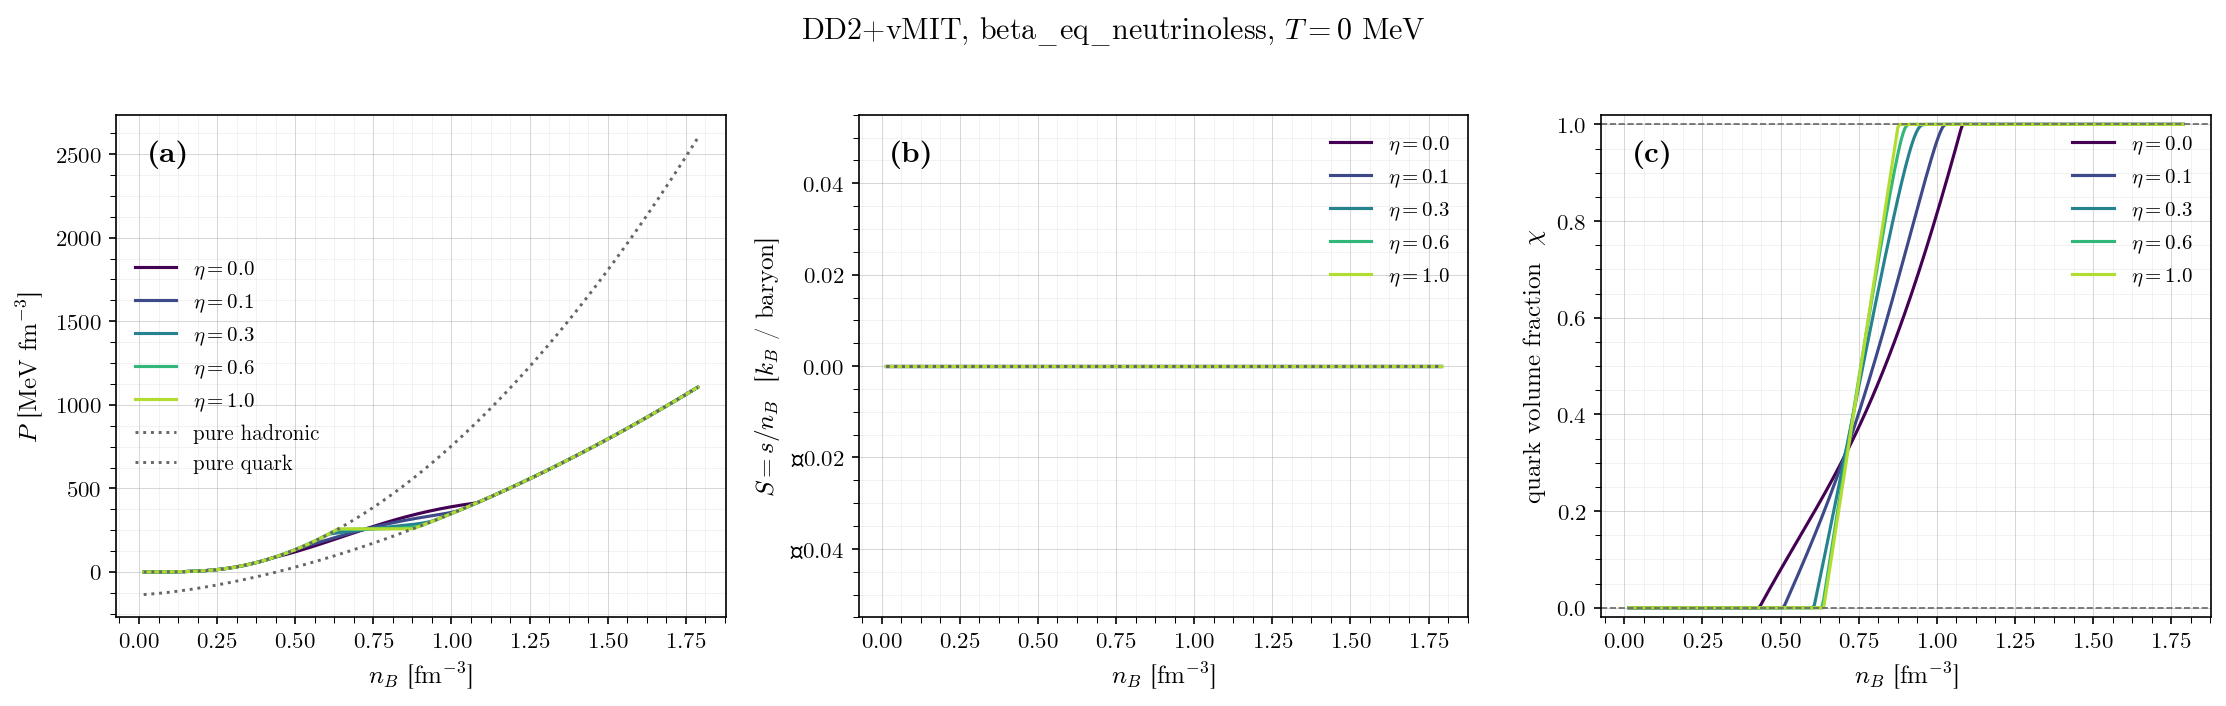

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


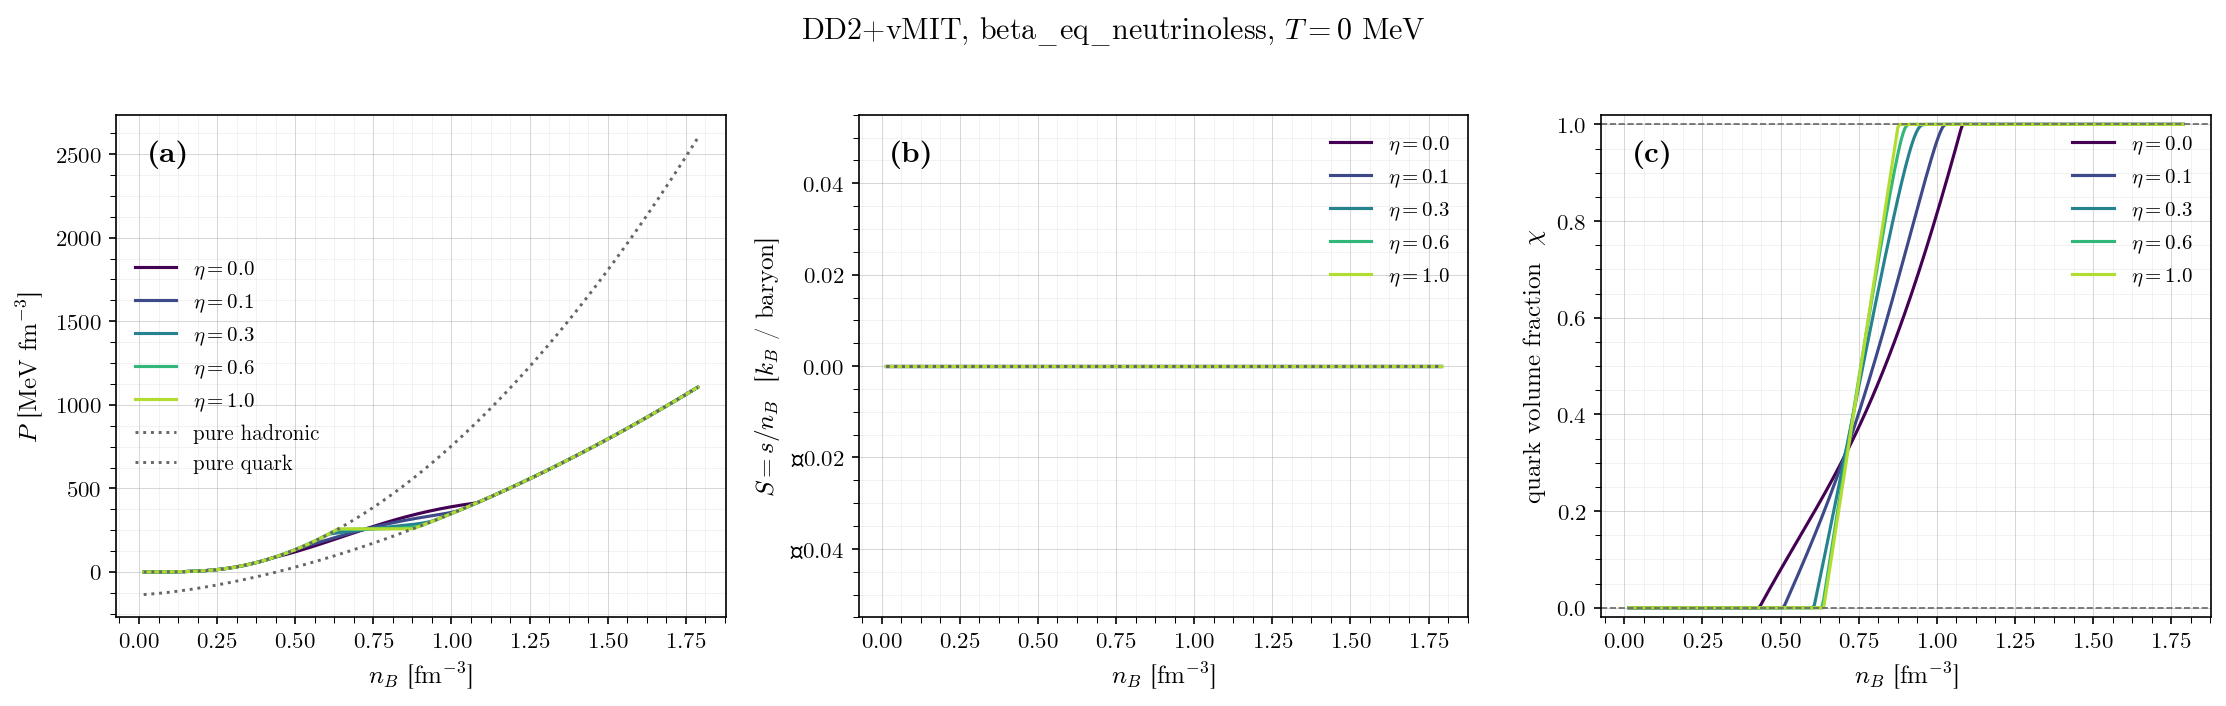

In [11]:
def plot_eos_panels(T, show_pure=True):
    """P, S/n_B and chi against density at one temperature, one colour per eta.

    The pure branches are drawn dotted underneath and continued past the
    transition, where they are metastable, so the gain from the transition is
    visible rather than implied.
    """
    fig, axes = setup_scientific_figure(nrows=1, ncols=3, figsize=(15, 4.6))
    for eta in sorted(loaded):
        d = full_eos(eta, T)
        if not d:
            continue
        c = COLOR_OF[eta]
        for ax, key in zip(axes, ("P", "S_per_B", "chi")):
            ax.plot(d["n_B"], d[key], "-", color=c, label=rf"$\eta={eta}$")

    if show_pure:
        for pure, lab in ((pure_hadronic.get(T), "pure hadronic"),
                          (pure_quark.get(T), "pure quark")):
            if pure is None or not pure["n_B"].size:
                continue
            axes[0].plot(pure["n_B"], pure["P"], ":", lw=1.4,
                         color=STANDARD_COLORS["Gray"], label=lab)
            axes[1].plot(pure["n_B"], pure["S_per_B"], ":", lw=1.4,
                         color=STANDARD_COLORS["Gray"])

    axes[0].set_ylabel(LABELS["P"])
    axes[1].set_ylabel(LABELS["S"] + r"  [$k_B$ / baryon]")
    axes[2].set_ylabel(r"quark volume fraction  $\chi$")
    axes[2].set_ylim(-0.02, 1.02)
    for y in (0.0, 1.0):
        axes[2].axhline(y, color=STANDARD_COLORS["Gray"], lw=0.8, ls="--")
    for ax in axes:
        ax.set_xlabel(LABELS["nB"])
        apply_style(ax)
    add_panel_labels(axes)
    fig.suptitle(rf"DD2+vMIT, {MODE}, $T = {T:g}$ MeV", y=1.02)
    fig.tight_layout()
    plt.show()
    return fig


plot_eos_panels(0.0)

At T = 0 the entropy panel is identically zero. The same three panels at a finite
temperature from `T_LIST`:

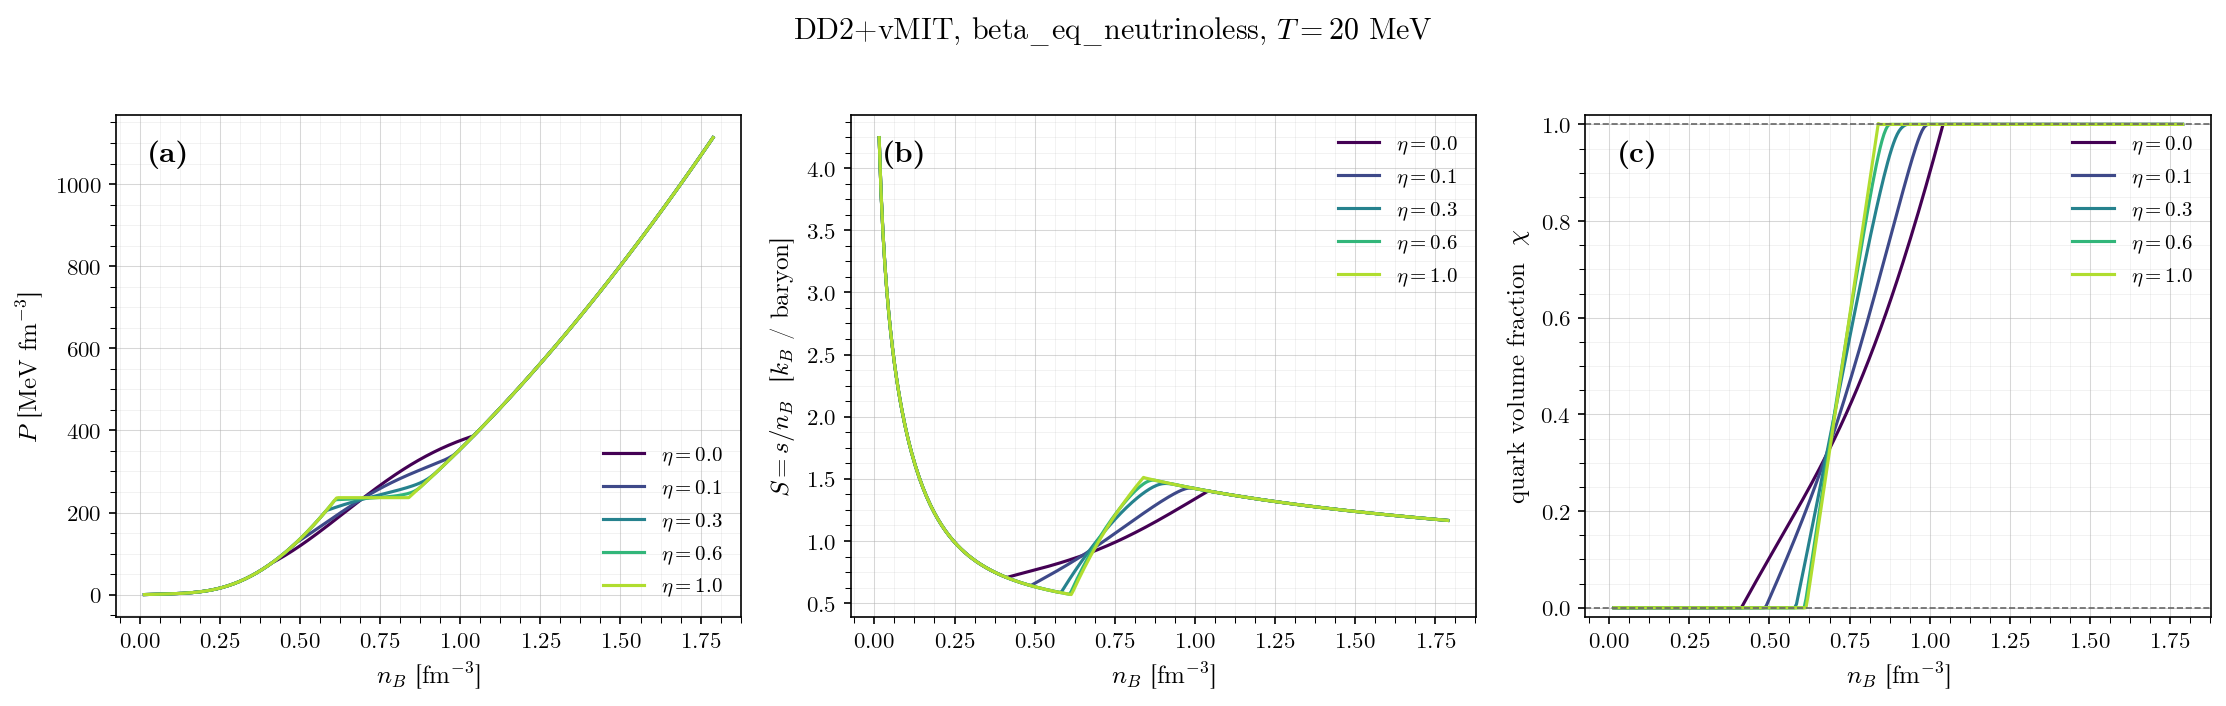

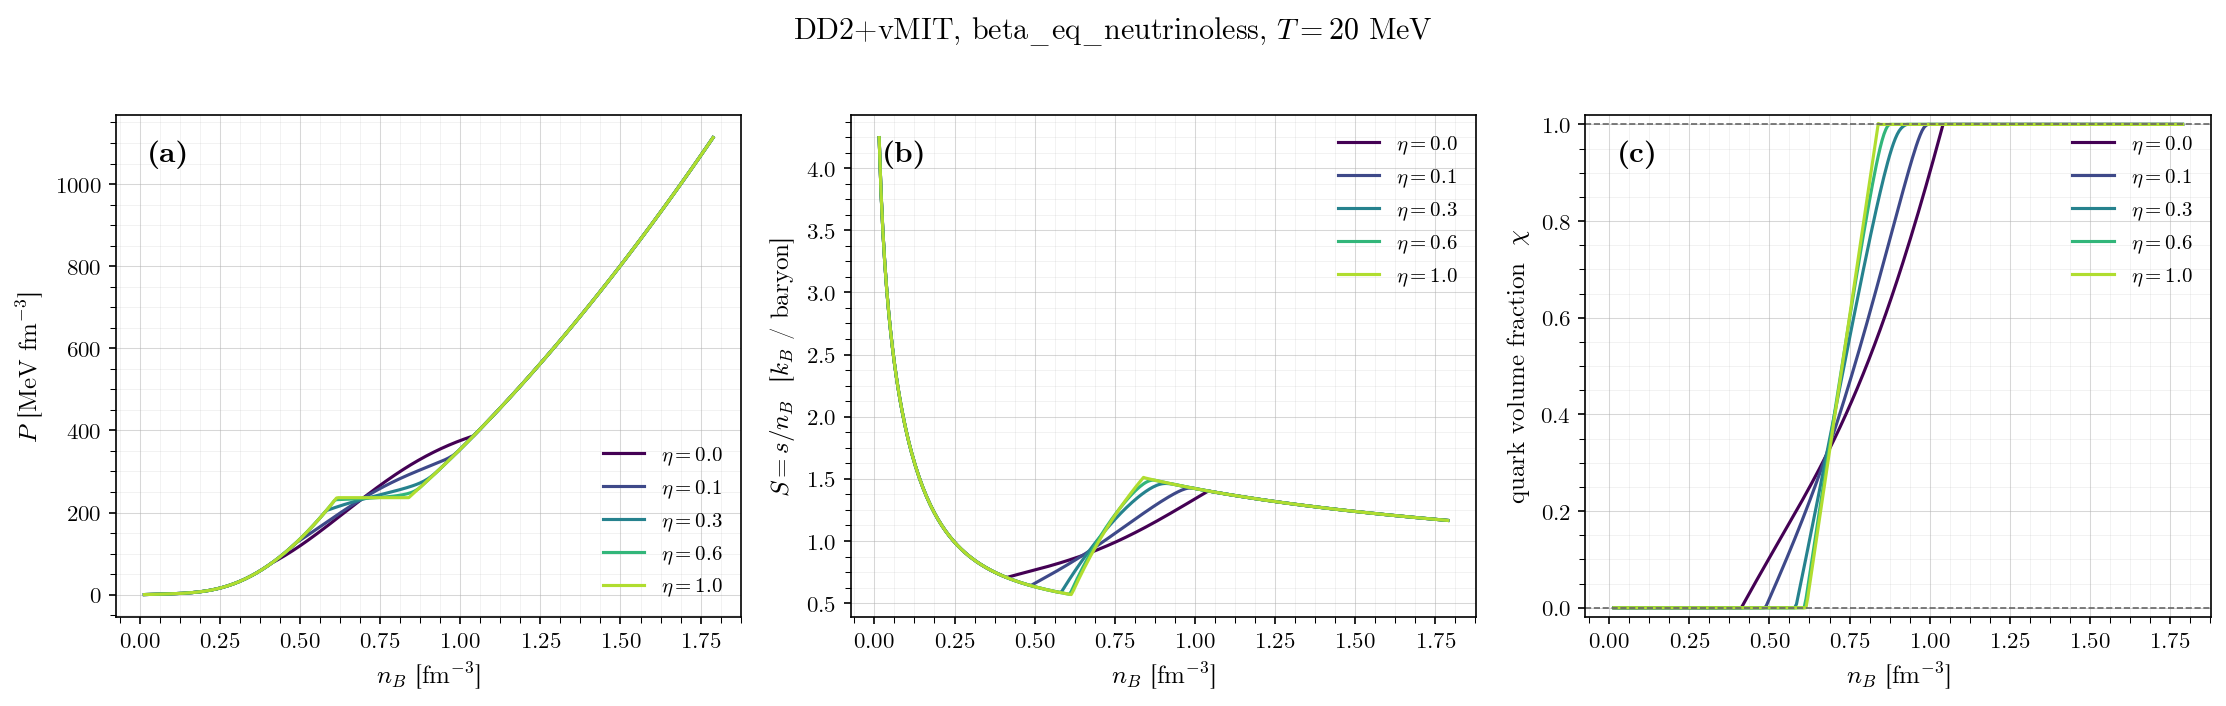

In [12]:
plot_eos_panels(20.0, show_pure=False)

## III.2 Phase boundaries in the (n_B, T) plane

For each η, the density at which the quark phase appears (χ = 0, onset) and the one
at which the hadronic phase disappears (χ = 1, offset), as functions of temperature.
The shaded band between them is the mixed phase. A wide band is Gibbs-like; the band
narrows towards η = 1, where it becomes the Maxwell density jump.

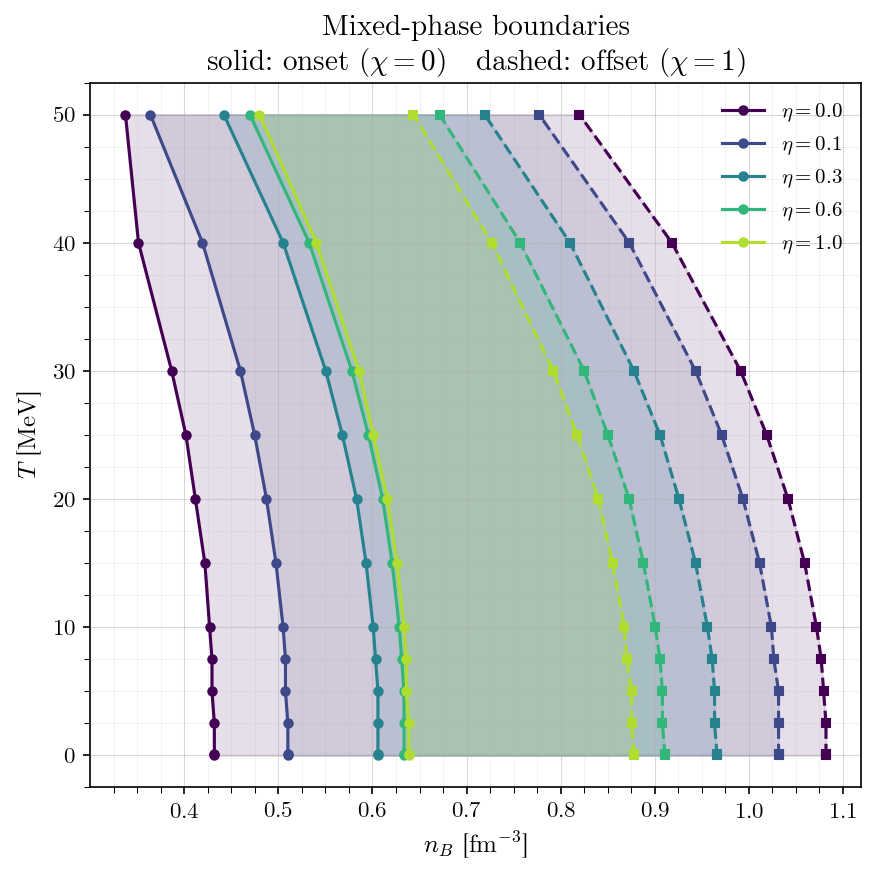

In [13]:
fig, ax = setup_scientific_figure()
for eta in ETA_LIST:
    wins = windows_by_eta.get(eta, {})
    Ts = sorted(k[0] for k in wins)
    onset = np.array([wins[(T,)].n_onset for T in Ts], dtype=float)
    offset = np.array([wins[(T,)].n_offset for T in Ts], dtype=float)
    good = np.isfinite(onset) & np.isfinite(offset)
    if not good.any():
        print(f"eta={eta}: no transition at any temperature")
        continue
    Ts = np.array(Ts, dtype=float)
    c = COLOR_OF[eta]
    ax.plot(onset[good], Ts[good], "-o", ms=4, color=c, label=rf"$\eta={eta}$")
    ax.plot(offset[good], Ts[good], "--s", ms=4, color=c)
    ax.fill_betweenx(Ts[good], onset[good], offset[good], color=c, alpha=0.13)

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["T"])
ax.set_title("Mixed-phase boundaries\n"
             "solid: onset ($\\chi=0$)   dashed: offset ($\\chi=1$)")
apply_style(ax)
fig.tight_layout()
plt.show()

## III.3 Mass-radius and tidal deformability

Cold, beta-equilibrium stars built on the stitched core equation of state, drawn
over the NICER and HESS credible regions and the PSR J0952-0607 mass band.

The overlays come from `eos.general.observational_constraints`, which reads contours
precomputed offline and shipped inside the package — nothing is refitted here. They
are drawn at low `zorder` so the model curves stay on top. Set `INLINE_LABELS=True`
to write each source name next to its blob instead of filling the legend with them.

/var/folders/rn/khnhjjpx5vn8wjc225vlrby40000gn/T/ipykernel_64286/3317039945.py:30: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.tight_layout()
/Users/mircoguerrini/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


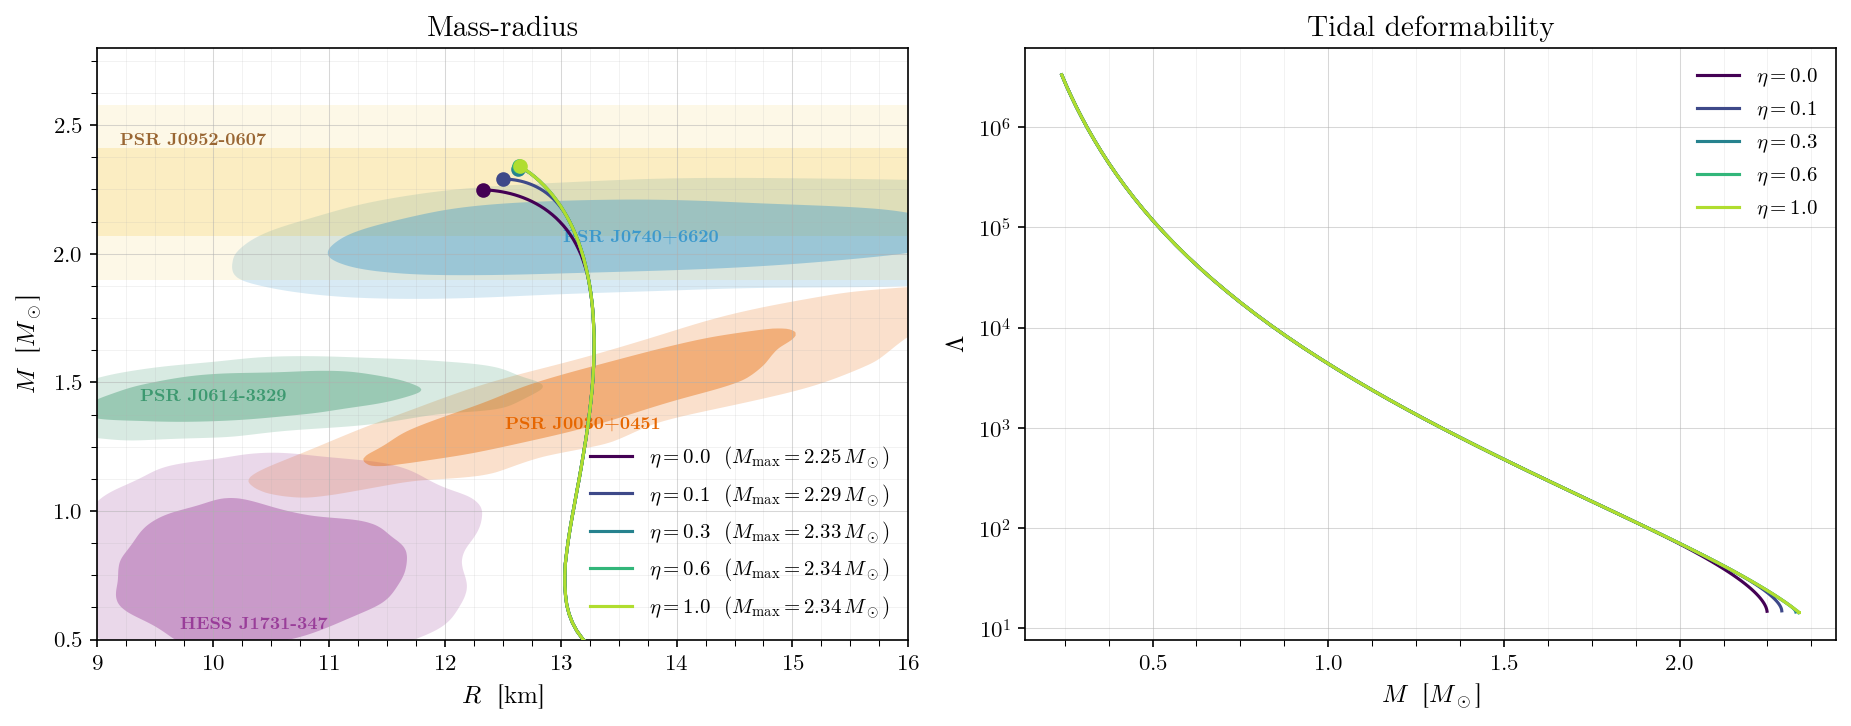

In [14]:
INLINE_LABELS = True

fig, axes = setup_scientific_figure(nrows=1, ncols=2, figsize=(12.5, 5))

# Constraints first, so the model curves are drawn over them.
add_observational_constraints(axes[0], inline_labels=INLINE_LABELS)

for eta, res in tov.items():
    r = res["results"]
    idx, _, M_max = find_mmax_precise(r)
    M, R, Lam = r[:idx + 1, 4], r[:idx + 1, 3], r[:idx + 1, 6]
    c = COLOR_OF.get(eta, STANDARD_COLORS["Gray"])
    axes[0].plot(R, M, "-", color=c, zorder=4,
                 label=rf"$\eta={eta}$  ($M_{{\max}}={M_max:.2f}\,M_\odot$)")
    axes[0].plot(res["R_Mmax"], M_max, "o", ms=6, color=c, zorder=5)
    axes[1].semilogy(M, Lam, "-", color=c, label=rf"$\eta={eta}$")

axes[0].set_xlabel(r"$R$  [km]")
axes[0].set_ylabel(r"$M$  [$M_\odot$]")
axes[0].set_title("Mass-radius")
# Pin the frame: the constraint blobs would otherwise stretch the axes out to
# wherever the widest posterior reaches.
axes[0].set_xlim(9.0, 16.0)
axes[0].set_ylim(0.5, 2.8)
axes[1].set_xlabel(r"$M$  [$M_\odot$]")
axes[1].set_ylabel(r"$\Lambda$")
axes[1].set_title("Tidal deformability")
for ax in axes:
    apply_style(ax)
fig.tight_layout()
plt.show()

## III.4 The two sound speeds

The clearest single picture of what η does.

**c_eq² = dP/dε** is taken along the equilibrium sequence, where the quark fraction χ
is free to readjust. A compression is then answered by converting hadrons into
quarks instead of by raising the pressure, so c_eq **dips** through a Gibbs window
and **collapses to zero** through a Maxwell one, where the pressure is flat by
construction. This is the sound speed that enters the TOV equations.

**c_ad² (frozen)** holds χ fixed — the mixture is compressed faster than one phase
can convert into the other — so the pressure has to rise and c_ad does *not*
collapse. Freezing χ is the part that matters; freezing only the charge fractions
would let the solve slide back onto the plateau.

The grey band is the causal bound c² ≤ 1. Both curves respect it; the interesting
feature is the gap between them, which widens with η.

`sound_speed_frozen` re-solves each phase twice per point, so this cell costs a few
seconds per η — it is the only expensive plot in Part III.

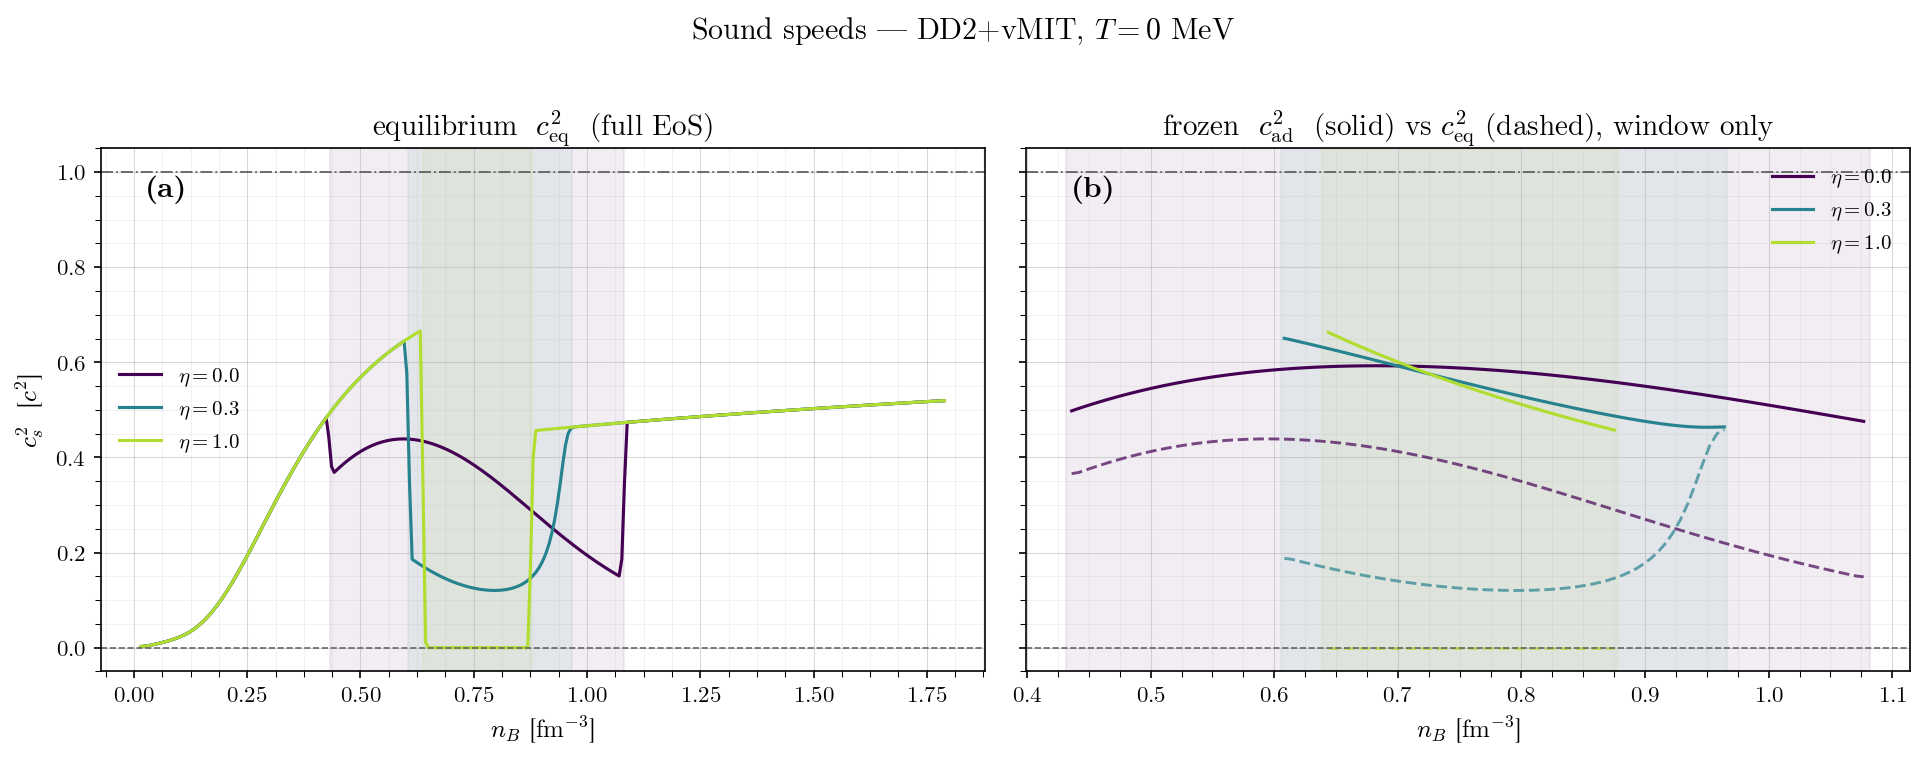

In [15]:
CS_ETAS = [e for e in (0.0, 0.3, 1.0) if e in ETA_LIST]

fig, axes = setup_scientific_figure(nrows=1, ncols=2, figsize=(13, 5),
                                    sharey=True)
for eta in CS_ETAS:
    c = COLOR_OF.get(eta, STANDARD_COLORS["Gray"])
    w = locate_window(PAR, FLAGS, NB, eta, beta_eq_neutrinoless(),
                      vmit_params=VMIT, T=0.0)
    if not w.exists:
        print(f"eta={eta}: no window, skipped")
        continue
    # Equilibrium: read straight off the stitched table, which already spans the
    # hadronic wing, the window and the quark wing.
    core = build_mixed_eos_table(PAR, FLAGS, NB, eta, beta_eq_neutrinoless(),
                                 vmit_params=VMIT, T=0.0, window=w)
    axes[0].plot(core.n_B, sound_speed_eq(core.P, core.eps), "-", color=c,
                 label=rf"$\eta={eta}$")

    # Frozen: only defined where there are two phases, so it is drawn across the
    # window and its two endpoints.
    inside = NB[(NB >= w.n_onset) & (NB <= w.n_offset)]
    rs = sweep_mixed(PAR, FLAGS, inside, eta, beta_eq_neutrinoless(),
                     vmit_params=VMIT, T=0.0)
    n_mix = np.array([r.n_B for r in rs])
    axes[1].plot(n_mix, frozen_along(PAR, FLAGS, rs, vmit_params=VMIT),
                 "-", color=c, label=rf"$\eta={eta}$")
    axes[1].plot(n_mix, sound_speed_eq(np.array([r.P for r in rs]),
                                       np.array([r.eps for r in rs])),
                 "--", lw=1.4, color=c, alpha=0.7)
    for ax in axes:
        ax.axvspan(w.n_onset, w.n_offset, color=c, alpha=0.07, zorder=0)

for ax, title in zip(axes, ("equilibrium  $c_{\\rm eq}^2$  (full EoS)",
                            "frozen  $c_{\\rm ad}^2$  (solid) vs "
                            "$c_{\\rm eq}^2$ (dashed), window only")):
    ax.axhline(1.0, color=STANDARD_COLORS["Gray"], lw=0.9, ls="-.")
    ax.axhline(0.0, color=STANDARD_COLORS["Gray"], lw=0.8, ls="--")
    ax.set_xlabel(LABELS["nB"])
    ax.set_title(title)
    apply_style(ax)
axes[0].set_ylabel(r"$c_s^2$  [$c^2$]")
axes[0].set_ylim(-0.05, 1.05)
add_panel_labels(axes)
fig.suptitle(rf"Sound speeds — DD2+vMIT, $T = 0$ MeV", y=1.01)
fig.tight_layout()
plt.show()

## III.5 Parameter map — where the hybrid star lives

The II.4 scan as a picture. Colour is the onset density where a complete transition
exists; hatched cells have none. With `SCAN_TOV` on, the contour marks
M_max = 2.0 M_sun, so the region that is both hybrid *and* heavy enough to be
allowed is the coloured area on the heavy side of that line.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


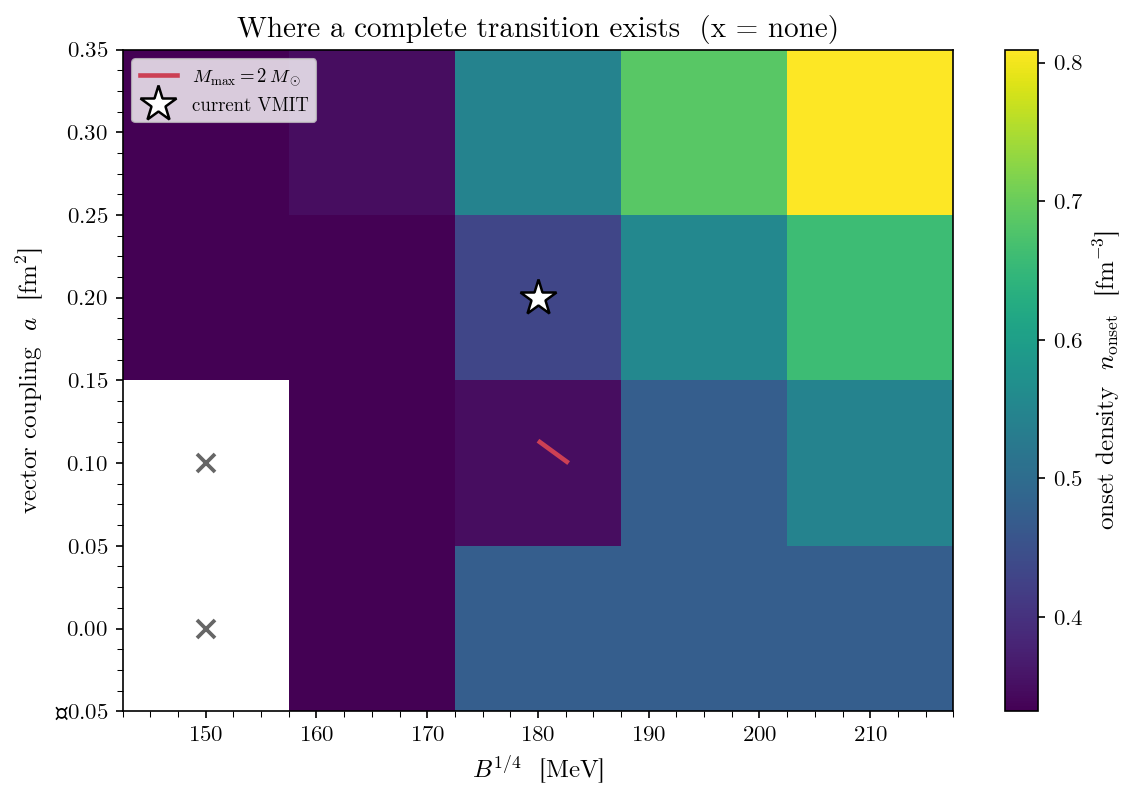

In [16]:
_B4 = np.array(sorted({r["B4"] for r in scan_rows}))
_A = np.array(sorted({r["a"] for r in scan_rows}))
_shape = (len(_A), len(_B4))
_onset = np.full(_shape, np.nan)
_mmax = np.full(_shape, np.nan)
for r in scan_rows:
    i, j = np.searchsorted(_A, r["a"]), np.searchsorted(_B4, r["B4"])
    if r["window_exists"]:
        _onset[i, j] = r["n_onset"]
    _mmax[i, j] = r.get("M_max", np.nan)

fig, ax = setup_scientific_figure(figsize=(8, 5.5))
# Sequential field -> viridis, per the palette convention in figure_style.
_im = ax.pcolormesh(_B4, _A, _onset, shading="nearest", cmap="viridis")
fig.colorbar(_im, ax=ax, label=r"onset density  $n_{\rm onset}$  [fm$^{-3}$]")
# Mark the combinations with no transition, which nan leaves blank.
for i, a in enumerate(_A):
    for j, b in enumerate(_B4):
        if not np.isfinite(_onset[i, j]):
            ax.plot(b, a, "x", color=STANDARD_COLORS["Gray"], ms=9, mew=1.8)
if SCAN_TOV and np.isfinite(_mmax).any():
    _red = STANDARD_COLORS["Red"]
    ax.contour(_B4, _A, _mmax, levels=[2.0], colors=[_red], linewidths=2.2)
    ax.plot([], [], "-", color=_red, lw=2.2, label=r"$M_{\max}=2\,M_\odot$")
ax.plot(VMIT.B4, VMIT.a, "*", color="white", ms=18, mec="k", mew=1.2,
        label="current VMIT")
ax.set_xlabel(r"$B^{1/4}$  [MeV]")
ax.set_ylabel(r"vector coupling  $a$  [fm$^2$]")
ax.set_title("Where a complete transition exists  (x = none)")
# A heatmap wants no gridlines over it; the legend still comes from apply_style.
apply_style(ax, grid=False, minor_grid=False)
ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

## III.6 Composition through the transition

Volume-weighted fractions Y_i = w n_i / n_B, with w = 1−χ for hadrons and w = χ for
quarks, so the curves sum consistently across the mixed phase. Hadrons solid, quarks
dashed. Shown across the whole density range: hadrons start at their pure values, hand
over through the window, and are gone above the offset, where the quarks reach their
pure ones. The shading marks the mixed window.


/var/folders/rn/khnhjjpx5vn8wjc225vlrby40000gn/T/ipykernel_64286/3104311258.py:33: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.tight_layout()
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with 

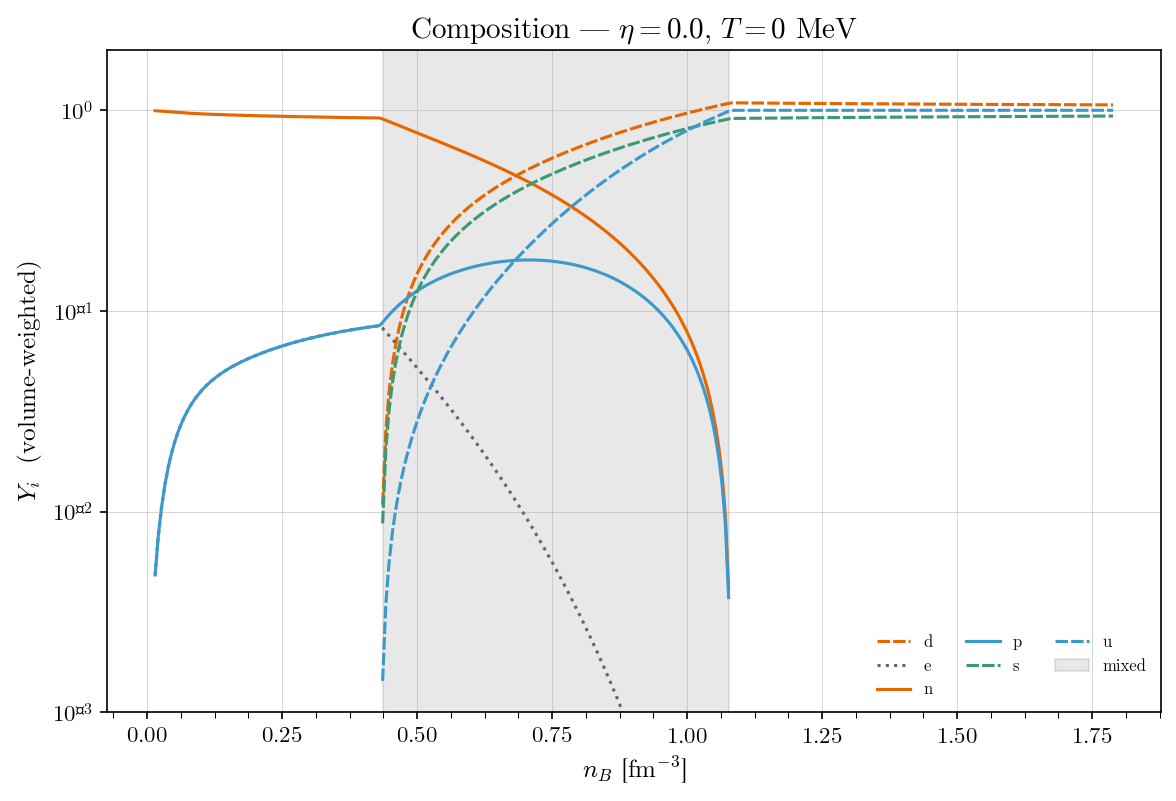

In [17]:
ETA_COMP = 0.0
T_COMP = 0.0
Y_FLOOR = 1e-3

d = full_eos(ETA_COMP, T_COMP)
species = sorted(k[2:] for k in d
                 if k.startswith("Y_") and k not in ("Y_C", "Y_S"))

fig, ax = setup_scientific_figure(figsize=(8, 5.5))
for sp in species:
    y = d[f"Y_{sp}"]
    if not np.isfinite(y).any() or np.nanmax(y) < Y_FLOOR:
        continue
    # Colour by particle and linestyle by multiplet, from the shared table:
    # nucleons solid, hyperons dashed, Deltas dash-dot, quarks densely dashed,
    # leptons dotted — so the figure survives being printed in black and white.
    colour, style = particle_style(sp)
    ax.plot(d["n_B"], y, ls=style, color=colour, label=sp)

mixed = (d["chi"] > 0.0) & (d["chi"] < 1.0)
if mixed.any():
    ax.axvspan(d["n_B"][mixed].min(), d["n_B"][mixed].max(),
               color=STANDARD_COLORS["Gray"], alpha=0.15, zorder=0,
               label="mixed")
ax.set_yscale("log")
ax.set_ylim(Y_FLOOR, 2.0)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["Y_i"] + r"  (volume-weighted)")
ax.set_title(rf"Composition — $\eta={ETA_COMP}$, $T={T_COMP:g}$ MeV")
# Minor gridlines are noise under a log axis with this many curves.
apply_style(ax, minor_grid=False)
ax.legend(ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
plt.show()